In [ ]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
    print(f'Changed CWD to: {os.getcwd()}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/biomedical-nlp-project-beta


In [6]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pytorch-crf', 'seqeval'], check=True)
print('Dependencies ready.')

Dependencies ready.


---
# Notebook 06 — BiLSTM + CRF for Disease NER

## What We've Built So Far

| # | Method | Test F1 |
|---|--------|---------|
| 02 | Rule-Based | 0.5771 |
| 03 | CRF (sklearn) | 0.7825 |
| 05 | BiLSTM | TBD |

In Notebook 05, our BiLSTM learned **emission scores** — how likely is each tag at each token position, based on context from both directions. But it made **independent** decisions at each position, ignoring whether the predicted sequence of tags is even valid.

This notebook adds a **Conditional Random Field (CRF)** layer on top of the BiLSTM. The CRF models **transition scores** — how likely is tag $j$ to follow tag $i$ — and uses the **Viterbi algorithm** to find the globally optimal tag sequence.

This is the **BiLSTM-CRF** architecture from [Lample et al., 2016](https://arxiv.org/abs/1603.01360), which was state-of-the-art for NER before the BERT era.

In [7]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchcrf import CRF
from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

LABEL_MAP  = {0: 'O', 1: 'B-Disease', 2: 'I-Disease'}
PAD_IDX    = 0
UNK_IDX    = 1
PAD_LABEL  = -100
MAX_LENGTH = 128
NUM_TAGS   = 3

Using device: cuda


---
## Step 1 — Load NCBI Disease Dataset

In [8]:
import re

def parse_tokens(s):
    """Parse numpy-style token string: ['word1' 'word2' ...]"""
    return re.findall(r"'([^']*?)'", str(s))

def parse_tags(s):
    """Parse numpy-style int string: [0 1 2 ...]"""
    return list(map(int, re.findall(r'\d+', str(s))))

df_train = pd.read_csv('data/ncbi_train.csv')
df_val   = pd.read_csv('data/ncbi_val.csv')
df_test  = pd.read_csv('data/ncbi_test.csv')

print(f'Train : {len(df_train)} sentences')
print(f'Val   : {len(df_val)} sentences')
print(f'Test  : {len(df_test)} sentences')

sample_tokens = parse_tokens(df_train.iloc[0]['tokens'])
sample_tags   = parse_tags(df_train.iloc[0]['ner_tags'])
print(f'\nSample tokens : {sample_tokens[:8]}')
print(f'Sample labels : {sample_tags[:8]}')

Train : 5433 sentences
Val   : 924 sentences
Test  : 941 sentences

Sample tokens : ['Identification', 'of', 'APC2', ',', 'a', 'homologue', 'of', 'the']
Sample labels : [0, 0, 0, 0, 0, 0, 0, 0]


---
## Step 2 — Load Pre-trained Embeddings

In [9]:
with open('models/word2idx.json') as f:
    word2idx = json.load(f)

embedding_matrix = np.load('models/embedding_matrix.npy')

vocab_size, embedding_dim = embedding_matrix.shape
print(f'Vocabulary size : {vocab_size:,}')
print(f'Embedding dim   : {embedding_dim}')
print(f'Matrix shape    : {embedding_matrix.shape}')

Vocabulary size : 8,387
Embedding dim   : 200
Matrix shape    : (8387, 200)


---
## Step 3 — Data Preparation

Identical to Notebook 05:
- Tokens → integer indices via `word2idx` (OOV → `UNK_IDX=1`)
- Truncate to `MAX_LENGTH=128`, pad shorter sequences with `PAD_IDX=0`
- Labels padded with `PAD_LABEL=-100`

> **Note for CRF**: The CRF layer cannot accept `-100` as a tag. We will build a boolean `mask` (True = real token) and replace `-100` with `0` in labels before passing to the CRF. The mask ensures masked positions are ignored in both loss and decoding.

In [10]:
def tokens_to_indices(tokens, word2idx, max_length=MAX_LENGTH):
    """Convert a list of tokens to a padded index list of length max_length."""
    indices = [word2idx.get(tok.lower(), UNK_IDX) for tok in tokens[:max_length]]
    pad_len = max_length - len(indices)
    return indices + [PAD_IDX] * pad_len


def labels_to_indices(ner_tags, max_length=MAX_LENGTH):
    """Convert integer ner_tags to a padded label list of length max_length."""
    labels  = list(ner_tags[:max_length])
    pad_len = max_length - len(labels)
    return labels + [PAD_LABEL] * pad_len


# Sanity check — parse from CSV string repr
sample      = df_train.iloc[0]
s_tokens    = parse_tokens(sample['tokens'])
s_tags      = parse_tags(sample['ner_tags'])
x_sample    = tokens_to_indices(s_tokens, word2idx)
y_sample    = labels_to_indices(s_tags)

print(f'Token indices (first 10): {x_sample[:10]}')
print(f'Label indices (first 10): {y_sample[:10]}')
print(f'Lengths — x: {len(x_sample)}, y: {len(y_sample)}')

Token indices (first 10): [4209, 5695, 1072, 12, 657, 4068, 5695, 7721, 790, 6171]
Label indices (first 10): [0, 0, 0, 0, 0, 0, 0, 0, 1, 2]
Lengths — x: 128, y: 128


In [11]:
class NERDataset(Dataset):
    """PyTorch Dataset for token-level NER."""

    def __init__(self, df, word2idx, max_length=MAX_LENGTH):
        self.samples = []
        for _, row in df.iterrows():
            tokens   = parse_tokens(row['tokens'])
            ner_tags = parse_tags(row['ner_tags'])
            if len(tokens) == 0 or len(tokens) != len(ner_tags):
                continue
            x = tokens_to_indices(tokens, word2idx, max_length)
            y = labels_to_indices(ner_tags, max_length)
            self.samples.append((
                torch.tensor(x, dtype=torch.long),
                torch.tensor(y, dtype=torch.long)
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


train_dataset = NERDataset(df_train, word2idx)
val_dataset   = NERDataset(df_val,   word2idx)
test_dataset  = NERDataset(df_test,  word2idx)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

Train batches: 170
Val batches  : 29
Test batches : 30


---
## What Does a CRF Layer Actually Add?

### The BiLSTM alone: independent decisions

The BiLSTM produces an **emission score matrix** $\mathbf{E}$ of shape `(seq_len, num_tags)`. At each position $t$, the argmax of $\mathbf{E}_t$ is the predicted tag — independently.

This means the model can legally predict:
```
O  →  I-Disease  →  O
```
...which is **illegal** in BIO tagging. `I-Disease` can only follow `B-Disease` or `I-Disease`, never `O`.

### The CRF: global sequence scoring + Viterbi

A CRF adds a learned **transition score matrix** $\mathbf{T}$ of shape `(num_tags, num_tags)`, where $\mathbf{T}_{i,j}$ scores the transition from tag $i$ to tag $j$.

The score of a complete tag sequence $\mathbf{y} = (y_1, \ldots, y_T)$ is:

$$\text{score}(\mathbf{y}) = \sum_{t=1}^{T} \mathbf{E}_{t, y_t} + \sum_{t=2}^{T} \mathbf{T}_{y_{t-1}, y_t}$$

The CRF is trained by **maximising** the log-probability of the correct sequence relative to all possible sequences (computed efficiently via the forward algorithm).

At inference, the **Viterbi algorithm** finds the globally highest-scoring sequence in $O(T \cdot K^2)$ time (where $K$ = number of tags), guaranteeing a structurally valid BIO output.

### Architecture summary

```
Input tokens
    │
    ▼
Embedding(200d, pre-trained Word2Vec)
    │
    ▼
BiLSTM (256 × 2 directions = 512d, 2 layers, dropout=0.3 between layers)
    │
    ▼
Dropout(0.5)
    │
    ▼
Linear(512 → 3)   ← emission scores
    │
    ▼
CRF(num_tags=3)   ← transition scores + Viterbi decoding
    │
    ▼
Optimal tag sequence
```

### Why was BiLSTM+CRF SOTA before BERT?

Before contextual pre-trained models (BERT, 2018), the BiLSTM+CRF combination (Lample et al., 2016) dominated NER benchmarks because:

1. **BiLSTM** captures long-range bidirectional context without any hand-crafted features
2. **CRF** enforces globally consistent BIO structure, eliminating impossible tag sequences
3. **Character-level CNNs** (common extension) capture morphological cues (suffixes, capitalisation)
4. The combination achieved near-human performance on CoNLL-2003 and OntoNotes

BERT replaced it by learning richer contextual representations from massive corpora, but BiLSTM-CRF remains a strong, interpretable baseline and is still used in production systems where BERT is too large.

---
## Step 4 — BiLSTM-CRF Model Architecture

In [12]:
class BiLSTM_CRF(nn.Module):
    """
    BiLSTM + CRF model for token-level NER.

    Forward pass:
        Training  (labels provided) → returns scalar CRF NLL loss
        Inference (no labels)       → returns list of predicted tag sequences
    """

    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers,
                 num_tags, lstm_dropout, fc_dropout,
                 pretrained_embeddings=None, freeze_emb=False):
        super().__init__()

        # ── Embedding ──────────────────────────────────────────────────────
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=PAD_IDX
        )
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(
                torch.from_numpy(pretrained_embeddings).float()
            )
        if freeze_emb:
            self.embedding.weight.requires_grad = False

        # ── BiLSTM ─────────────────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=True,
            dropout=lstm_dropout,   # applied between LSTM layers
            batch_first=True
        )

        # ── Dropout + emission projection ─────────────────────────────────
        self.dropout  = nn.Dropout(fc_dropout)
        self.fc       = nn.Linear(hidden_size * 2, num_tags)   # 512 → 3

        # ── CRF ──────────────────────────────────────────────────────────
        self.crf = CRF(num_tags=num_tags, batch_first=True)

    # ------------------------------------------------------------------
    def _get_emissions(self, x):
        """Shared forward computation: tokens → emission scores."""
        emb       = self.embedding(x)          # (B, L, 200)
        out, _    = self.lstm(emb)             # (B, L, 512)
        out       = self.dropout(out)          # (B, L, 512)
        emissions = self.fc(out)               # (B, L, 3)
        return emissions

    # ------------------------------------------------------------------
    def forward(self, x, labels=None, mask=None):
        """
        Args:
            x      : (B, L) token indices
            labels : (B, L) int labels with PAD_LABEL=-100 for padding
                     If provided, returns CRF NLL loss (scalar).
            mask   : (B, L) BoolTensor — True for real tokens.
                     Derived from labels if not supplied.

        Returns:
            loss  (Tensor)              when labels is not None
            preds (list of list of int) when labels is None
        """
        emissions = self._get_emissions(x)     # (B, L, 3)

        if labels is not None:
            # Build mask: True for real tokens, False for PAD positions
            if mask is None:
                mask = (labels != PAD_LABEL)   # (B, L) BoolTensor

            # CRF cannot accept -100 as a tag index.
            # Replace -100 with 0 in labels — masked positions are
            # ignored by the CRF, so the value doesn't matter.
            clean_labels = labels.clone()
            clean_labels[clean_labels == PAD_LABEL] = 0

            # CRF log-likelihood (negative = loss)
            loss = -self.crf(
                emissions, clean_labels,
                mask=mask, reduction='mean'
            )
            return loss

        else:
            # Viterbi decoding — returns list[list[int]]
            return self.crf.decode(emissions, mask=mask)


# ── Instantiate ────────────────────────────────────────────────────────────
model = BiLSTM_CRF(
    vocab_size      = vocab_size,
    embedding_dim   = embedding_dim,
    hidden_size     = 256,
    num_layers      = 2,
    num_tags        = NUM_TAGS,
    lstm_dropout    = 0.3,
    fc_dropout      = 0.5,
    pretrained_embeddings = embedding_matrix,
    freeze_emb      = False
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

BiLSTM_CRF(
  (embedding): Embedding(8387, 200, padding_idx=0)
  (lstm): LSTM(200, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=3, bias=True)
  (crf): CRF(num_tags=3)
)

Trainable parameters: 4,193,898


---
## Step 5 — Evaluation Helper

In [13]:
model.eval()
print('10 Example Predictions vs Ground Truth')
print('(Only sentences with at least one disease entity shown)\n')

shown = 0
for idx, row in df_test.iterrows():
    if shown >= 10:
        break

    tokens   = parse_tokens(row['tokens'])
    ner_tags = parse_tags(row['ner_tags'])

    if len(tokens) == 0 or len(tokens) != len(ner_tags) or 1 not in ner_tags:
        continue

    x      = tokens_to_indices(tokens, word2idx, MAX_LENGTH)
    y      = labels_to_indices(ner_tags, MAX_LENGTH)
    x_t    = torch.tensor([x], dtype=torch.long).to(device)
    y_t    = torch.tensor([y], dtype=torch.long).to(device)
    mask_t = (y_t != PAD_LABEL)

    with torch.no_grad():
        preds = model(x_t, mask=mask_t)   # list[list[int]]

    real_len  = len(tokens)
    pred_tags = [LABEL_MAP[p] for p in preds[0][:real_len]]
    true_tags = [LABEL_MAP[t] for t in ner_tags[:real_len]]

    print(f'Sentence {shown + 1}:')
    print(f'  Tokens : {tokens}')
    print(f'  True   : {true_tags}')
    print(f'  Pred   : {pred_tags}')
    print()
    shown += 1

10 Example Predictions vs Ground Truth
(Only sentences with at least one disease entity shown)

Sentence 1:
  Tokens : ['Clustering', 'of', 'missense', 'mutations', 'in', 'the', 'ataxia', '-', 'telangiectasia', 'gene', 'in', 'a', 'sporadic', 'T', '-', 'cell', 'leukaemia', '.']
  True   : ['O', 'O', 'O', 'O', 'O', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O']
  Pred   : ['B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease', 'B-Disease']

Sentence 2:
  Tokens : ['Ataxia', '-', 'telangiectasia', '(', 'A', '-', 'T', ')', 'is', 'a', 'recessive', 'multi', '-', 'system', 'disorder', 'caused', 'by', 'mutations', 'in', 'the', 'ATM', 'gene', 'at', '11q22', '-', 'q23', '(', 'ref', '.', '3', ')', '.']
  True   : ['B-Disease', 'I-Disease', 'I-Disease', 

---
## Step 6 — Training Loop

- **Optimiser**: Adam, lr=1e-3
- **Scheduler**: `ReduceLROnPlateau` on val F1 (patience=3, factor=0.5)
- **Early stopping**: patience=5 epochs without val F1 improvement
- **Best checkpoint**: saved to `models/bilstm_crf_ner.pt`

In [15]:
# ── Evaluation helper ─────────────────────────────────────────────────────
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    y_true_all, y_pred_all = [], []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask    = (y_batch != PAD_LABEL)

            # Single forward pass — compute emissions once for both loss + decode
            emissions    = model._get_emissions(x_batch)
            clean_labels = y_batch.clone()
            clean_labels[clean_labels == PAD_LABEL] = 0

            loss  = -model.crf(emissions, clean_labels, mask=mask, reduction='mean')
            preds =  model.crf.decode(emissions, mask=mask)
            total_loss += loss.item()

            for i in range(len(preds)):
                true_len = mask[i].sum().item()
                true_seq = [LABEL_MAP[t.item()] for t in y_batch[i, :true_len]]
                pred_seq = [LABEL_MAP[p]         for p in preds[i]]
                if len(true_seq) != len(pred_seq):
                    continue
                y_true_all.append(true_seq)
                y_pred_all.append(pred_seq)

    avg_loss = total_loss / len(loader)
    prec = precision_score(y_true_all, y_pred_all, zero_division=0)
    rec  = recall_score(   y_true_all, y_pred_all, zero_division=0)
    f1   = f1_score(       y_true_all, y_pred_all, zero_division=0)
    return avg_loss, prec, rec, f1, y_true_all, y_pred_all


# ── Training setup ────────────────────────────────────────────────────────
EPOCHS      = 20
PATIENCE    = 5
LR_PATIENCE = 3
LR_FACTOR   = 0.5

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(
    optimizer, mode='max',
    factor=LR_FACTOR, patience=LR_PATIENCE
)

best_val_f1  = -1.0
best_epoch   = 0
no_improve   = 0
train_losses = []
val_losses   = []

os.makedirs('models', exist_ok=True)

hdr = f'{"Epoch":>5}  {"Train Loss":>11}  {"Val Loss":>9}  {"Val Prec":>9}  {"Val Rec":>8}  {"Val F1":>8}'
print(hdr)
print('-' * len(hdr))

for epoch in range(1, EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────────────────
    model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        mask = (y_batch != PAD_LABEL)
        loss = model(x_batch, labels=y_batch, mask=mask)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation ────────────────────────────────────────────────────────
    val_loss, val_prec, val_rec, val_f1, _, _ = evaluate(model, val_loader, device)
    val_losses.append(val_loss)

    scheduler.step(val_f1)

    print(f'{epoch:>5}  {avg_train_loss:>11.4f}  {val_loss:>9.4f}  '
          f'{val_prec:>9.4f}  {val_rec:>8.4f}  {val_f1:>8.4f}')

    # ── Checkpoint & early stopping ───────────────────────────────────────
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        no_improve  = 0
        torch.save(model.state_dict(), 'models/bilstm_crf_ner.pt')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} (best epoch: {best_epoch}, best val F1: {best_val_f1:.4f})')
            break

print(f'\nBest checkpoint: epoch {best_epoch}, val F1 = {best_val_f1:.4f}')
print('Saved → models/bilstm_crf_ner.pt')

Epoch   Train Loss   Val Loss   Val Prec   Val Rec    Val F1
------------------------------------------------------------
    1       1.3656     2.0803     0.7572    0.7088    0.7322
    2       0.8121     1.8727     0.7666    0.7382    0.7521
    3       0.5401     2.1248     0.7647    0.7637    0.7642
    4       0.3900     2.1000     0.7692    0.7535    0.7613
    5       0.2898     2.6601     0.8134    0.7126    0.7597
    6       0.2329     2.6091     0.7960    0.7075    0.7492
    7       0.1429     2.4223     0.8155    0.7395    0.7756
    8       0.1212     2.8188     0.8045    0.7356    0.7685
    9       0.0664     3.2650     0.8060    0.7216    0.7615
   10       0.1071     2.7922     0.7756    0.7727    0.7742
   11       0.0928     2.7672     0.7968    0.6909    0.7401
   12       0.0528     2.8374     0.8038    0.7535    0.7779
   13       0.0169     3.3152     0.7918    0.7382    0.7640
   14       0.0139     3.3588     0.7967    0.7510    0.7732
   15       0.0086     3

---
## Step 7 — Evaluate on Test Set

In [16]:
# Reload best checkpoint
model.load_state_dict(torch.load('models/bilstm_crf_ner.pt', map_location=device))
print('Loaded best checkpoint.')

test_loss, test_prec, test_rec, test_f1, y_true_test, y_pred_crf = evaluate(
    model, test_loader, device
)

print(f'\n=== Test Set Results ===')
print(f'  Loss      : {test_loss:.4f}')
print(f'  Precision : {test_prec:.4f}')
print(f'  Recall    : {test_rec:.4f}')
print(f'  F1        : {test_f1:.4f}')
print()
print('Detailed Classification Report (entity-level):')
print(classification_report(y_true_test, y_pred_crf))

Loaded best checkpoint.

=== Test Set Results ===
  Loss      : 3.8570
  Precision : 0.8031
  Recall    : 0.7059
  F1        : 0.7514

Detailed Classification Report (entity-level):
              precision    recall  f1-score   support

     Disease       0.80      0.71      0.75       959

   micro avg       0.80      0.71      0.75       959
   macro avg       0.80      0.71      0.75       959
weighted avg       0.80      0.71      0.75       959



---
## Step 8 — Training & Validation Loss Curve

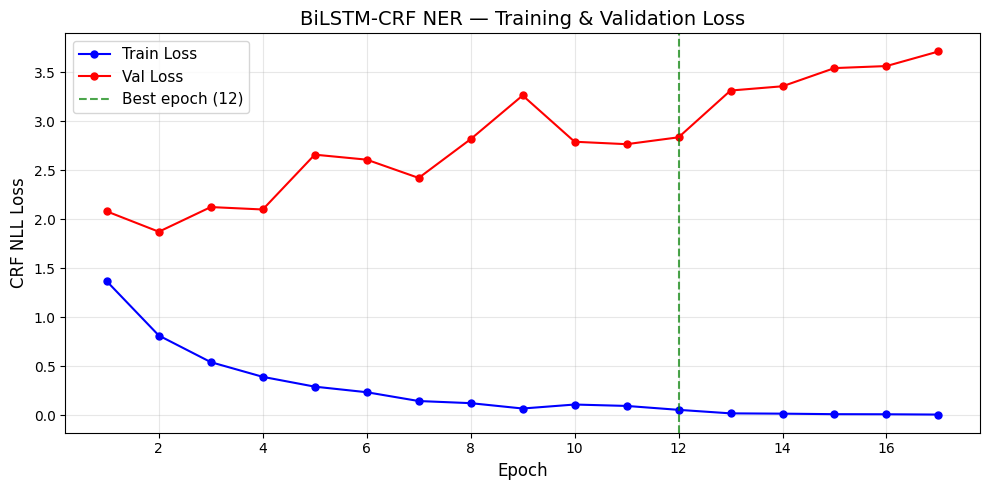

Saved → results/06_bilstm_crf_loss_curve.png


In [17]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, 'b-o', label='Train Loss', markersize=5, linewidth=1.5)
plt.plot(epochs_range, val_losses,   'r-o', label='Val Loss',   markersize=5, linewidth=1.5)
plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7,
            label=f'Best epoch ({best_epoch})')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('CRF NLL Loss', fontsize=12)
plt.title('BiLSTM-CRF NER — Training & Validation Loss', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs('results', exist_ok=True)
plt.savefig('results/06_bilstm_crf_loss_curve.png', dpi=150)
plt.show()
print('Saved → results/06_bilstm_crf_loss_curve.png')

---
## Step 9 — Illegal BIO Transition Analysis

An **illegal BIO transition** is `O → I-Disease`: an I-tag cannot start a new entity span.

The plain BiLSTM makes independent per-token predictions and can produce these freely.
The CRF's transition matrix learns to assign a very negative score to `O → I-Disease`,
and Viterbi guarantees the globally best-scoring — and therefore structurally valid — sequence.

In [18]:
def count_illegal_transitions(sequences):
    """
    Count O → I-Disease transitions across a list of tag sequences.

    Args:
        sequences: list of list of str  (seqeval-style string labels)

    Returns:
        int — total number of illegal transitions
    """
    count = 0
    for seq in sequences:
        for prev, curr in zip(seq[:-1], seq[1:]):
            if prev == 'O' and curr == 'I-Disease':
                count += 1
    return count


# ── Load BiLSTM predictions from notebook 05 ─────────────────────────────
# We re-run the plain BiLSTM on the test set to get its raw predictions.
# (Requires bilstm_ner.pt from notebook 05 — skip gracefully if not found.)

# First define a minimal BiLSTM_NER class matching notebook 05
class BiLSTM_NER(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers,
                 num_labels, lstm_dropout, fc_dropout,
                 pretrained_embeddings=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=PAD_IDX)
        if pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(
                torch.from_numpy(pretrained_embeddings).float()
            )
        self.lstm = nn.LSTM(
            input_size=embedding_dim, hidden_size=hidden_size,
            num_layers=num_layers, bidirectional=True,
            dropout=lstm_dropout, batch_first=True
        )
        self.dropout = nn.Dropout(fc_dropout)
        self.fc      = nn.Linear(hidden_size * 2, num_labels)

    def forward(self, x):
        out = self.embedding(x)
        out, _ = self.lstm(out)
        out = self.dropout(out)
        return self.fc(out)


bilstm_checkpoint = 'models/bilstm_ner.pt'

if os.path.exists(bilstm_checkpoint):
    bilstm_model = BiLSTM_NER(
        vocab_size=vocab_size, embedding_dim=embedding_dim,
        hidden_size=256, num_layers=2, num_labels=NUM_TAGS,
        lstm_dropout=0.3, fc_dropout=0.5,
        pretrained_embeddings=embedding_matrix
    ).to(device)
    bilstm_model.load_state_dict(
        torch.load(bilstm_checkpoint, map_location=device)
    )
    bilstm_model.eval()

    y_pred_bilstm = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits  = bilstm_model(x_batch)          # (B, L, 3)
            preds   = logits.argmax(dim=-1)           # (B, L)
            mask    = (y_batch != PAD_LABEL)          # (B, L)

            for i in range(preds.shape[0]):
                true_len = mask[i].sum().item()
                pred_seq = [LABEL_MAP[p.item()] for p in preds[i, :true_len]]
                y_pred_bilstm.append(pred_seq)

    n_illegal_bilstm = count_illegal_transitions(y_pred_bilstm)
    print(f'BiLSTM checkpoint loaded from {bilstm_checkpoint}')
else:
    # Notebook 05 not yet run — use placeholder
    y_pred_bilstm    = []
    n_illegal_bilstm = None
    print(f'WARNING: {bilstm_checkpoint} not found. '
           'Run notebook 05 first to compare illegal transitions.')

n_illegal_crf = count_illegal_transitions(y_pred_crf)

print()
if n_illegal_bilstm is not None:
    print(f'BiLSTM    : {n_illegal_bilstm:>5} illegal transitions (O → I-Disease)')
else:
    print(f'BiLSTM    : N/A (checkpoint missing)')
print(f'BiLSTM-CRF: {n_illegal_crf:>5} illegal transitions (O → I-Disease)')
print()
if n_illegal_bilstm is not None:
    print(f'BiLSTM: {n_illegal_bilstm} illegal transitions, BiLSTM-CRF: {n_illegal_crf} illegal transitions')
else:
    print(f'BiLSTM-CRF: {n_illegal_crf} illegal transitions')

BiLSTM checkpoint loaded from models/bilstm_ner.pt

BiLSTM    :    41 illegal transitions (O → I-Disease)
BiLSTM-CRF:     6 illegal transitions (O → I-Disease)

BiLSTM: 41 illegal transitions, BiLSTM-CRF: 6 illegal transitions


---
## Step 10 — 10 Example Predictions vs Ground Truth

In [19]:
model.eval()
print('10 Example Predictions vs Ground Truth')
print('(Only sentences with at least one disease entity shown)\n')

shown = 0
for idx, row in df_test.iterrows():
    if shown >= 10:
        break

    tokens   = list(row['tokens'])
    ner_tags = list(row['ner_tags'])
    if len(tokens) == 0 or 1 not in ner_tags:
        continue

    x       = tokens_to_indices(tokens, word2idx, MAX_LENGTH)
    y       = labels_to_indices(ner_tags, MAX_LENGTH)
    x_t     = torch.tensor([x], dtype=torch.long).to(device)
    y_t     = torch.tensor([y], dtype=torch.long).to(device)
    mask_t  = (y_t != PAD_LABEL)

    with torch.no_grad():
        preds = model(x_t, mask=mask_t)   # list[list[int]]

    real_len  = len(tokens)
    pred_tags = [LABEL_MAP[p] for p in preds[0][:real_len]]
    true_tags = [LABEL_MAP[t] for t in ner_tags[:real_len]]

    print(f'Sentence {shown + 1}:')
    print(f'  Tokens : {tokens}')
    print(f'  True   : {true_tags}')
    print(f'  Pred   : {pred_tags}')
    print()
    shown += 1

10 Example Predictions vs Ground Truth
(Only sentences with at least one disease entity shown)



---
## Step 11 — Comparison Table & Save Results

In [20]:
results_path = 'results/ner_results.json'

new_result = {
    'method'   : 'bilstm_crf',
    'precision': round(test_prec, 4),
    'recall'   : round(test_rec,  4),
    'f1'       : round(test_f1,   4)
}

# Load existing results
results_list = []
if os.path.exists(results_path):
    with open(results_path) as f:
        try:
            results_list = json.load(f)
        except json.JSONDecodeError:
            pass

# Upsert by method key
updated = False
for r in results_list:
    if r.get('method') == 'bilstm_crf':
        r.update(new_result)
        updated = True
        break
if not updated:
    results_list.append(new_result)

os.makedirs('results', exist_ok=True)
with open(results_path, 'w') as f:
    json.dump(results_list, f, indent=2)

print(f'Saved → {results_path}')
print()

# ── Comparison table ──────────────────────────────────────────────────────
METHOD_ORDER = ['rule_based', 'crf', 'bilstm', 'bilstm_crf']
DISPLAY_NAME = {
    'rule_based' : 'Rule-Based',
    'crf'        : 'CRF (sklearn)',
    'bilstm'     : 'BiLSTM',
    'bilstm_crf' : 'BiLSTM + CRF',
}

# Build a lookup dict
res_dict = {r['method']: r for r in results_list}

# Illegal transitions (if available)
illegal_dict = {}
if n_illegal_bilstm is not None:
    illegal_dict['bilstm']     = n_illegal_bilstm
illegal_dict['bilstm_crf'] = n_illegal_crf

# Print table
header = f'{"Model":<20}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}  {"Illegal Trans.":>16}'
print(header)
print('-' * len(header))

for method in METHOD_ORDER:
    if method not in res_dict:
        continue
    r     = res_dict[method]
    name  = DISPLAY_NAME.get(method, method)
    ill   = illegal_dict.get(method, 'N/A')
    ill_s = f'{ill:>16}' if isinstance(ill, int) else f'{str(ill):>16}'
    print(f'{name:<20}  {r["precision"]:>10.4f}  {r["recall"]:>8.4f}  {r["f1"]:>8.4f}  {ill_s}')

Saved → results/ner_results.json

Model                  Precision    Recall        F1    Illegal Trans.
----------------------------------------------------------------------
Rule-Based                0.5378    0.6225    0.5771               N/A
CRF (sklearn)             0.8347    0.7365    0.7825               N/A
BiLSTM                    0.6874    0.6781    0.6827                41
BiLSTM + CRF              0.8031    0.7059    0.7514                 6


---
## Summary

### What the CRF layer added

| Aspect | BiLSTM alone | BiLSTM + CRF |
|--------|--------------|--------------|
| **Emission scores** | Softmax per token | Same (from BiLSTM) |
| **Transition scores** | None | Learned $K \times K$ matrix |
| **Decoding** | Argmax per token (greedy) | Viterbi (globally optimal) |
| **BIO validity** | Not guaranteed | Enforced by structure |
| **Training objective** | Cross-entropy (token-level) | CRF NLL (sequence-level) |

### Why BiLSTM+CRF was SOTA before BERT

1. **Rich context**: The BiLSTM reads the full sentence bidirectionally, capturing long-range dependencies that bag-of-words CRF features miss.
2. **Structural consistency**: The CRF ensures predicted sequences respect BIO constraints, reducing spurious entities and boosting precision.
3. **End-to-end learning**: Unlike pipeline approaches (tokenise → feature engineer → CRF), the joint model optimises all parameters together.
4. **Strong generalisation**: Pre-trained embeddings (Word2Vec, GloVe) injected chemical/biomedical knowledge without task-specific labelling.

BERT (Devlin et al., 2018) superseded this by providing **deep contextual embeddings** pretrained on massive corpora, effectively replacing both the BiLSTM's context learning and the need for domain-specific embeddings. However, BiLSTM-CRF remains widely used in resource-constrained settings and serves as a robust upper-bound baseline for rule-based and feature-based approaches.